📥 正在加载 Cosine 数据: Hybrid
📥 正在加载 Cosine 数据: Dense
📥 正在加载 Cosine 数据: Bm25


C:\Users\user\AppData\Local\Temp\ipykernel_27472\2963118421.py:76: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_27472\2963118421.py:76: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.6}` instead.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_27472\2963118421.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=FS_TICK, fontweight='bold')
C:\Users\user\AppData\Local\Temp\ipykernel_27472\2963118421.py:76: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_27472\2963118421.py:76: FutureWarning: 

The `errwi

✅ Cosine 图表已保存至: C:\Users\user\FXR-水凝胶\2026-0226-0126基础上Agent-消融实验-para的\Agent\EVAL\BERT_COS\Final_Cosine_RowGrouped-paratry.png


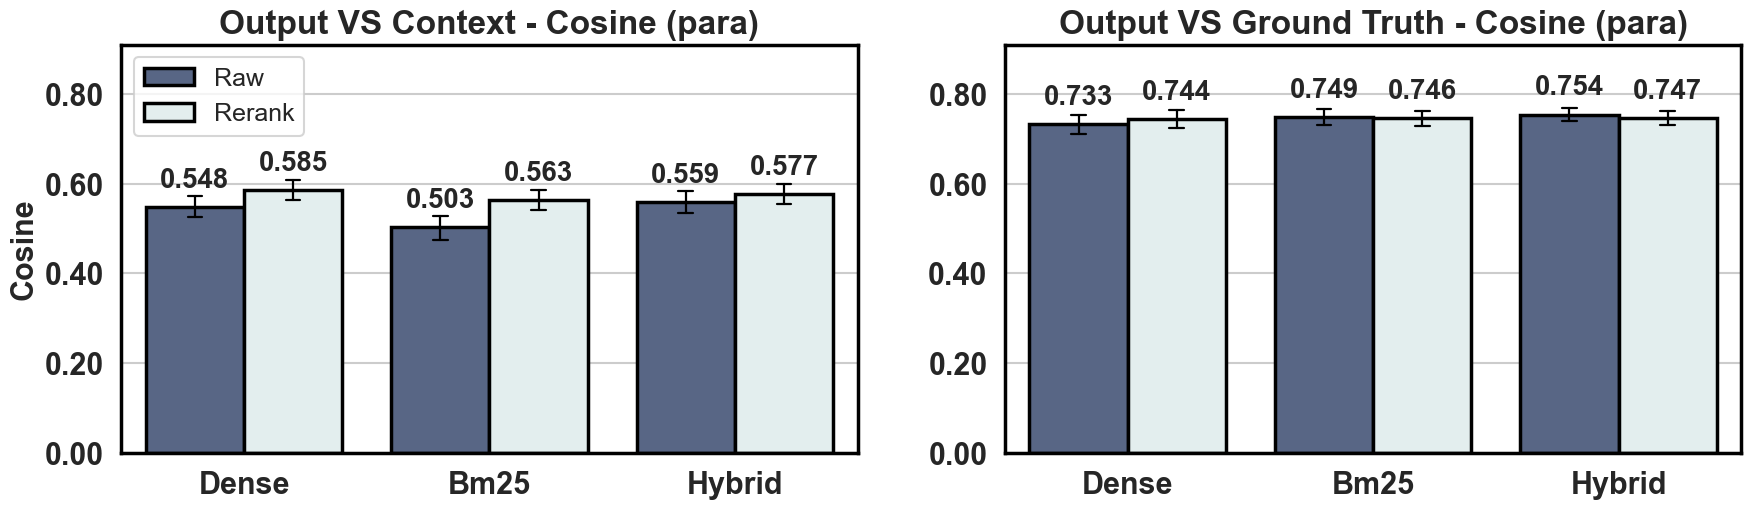

In [29]:
# -*- coding: utf-8 -*-
# BERT_COS
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FormatStrFormatter

BASE_DIR = r"..\para\BERT_COS"
OUTPUT_PLOT_PATH = os.path.join(BASE_DIR, "Final_Cosine_RowGrouped-paratry.png")

MODES = ["Hybrid", "Dense", "Bm25"]

# ===== 全局字号设置 =====
FS_TITLE = 24         # 子图标题
FS_LABEL = 22         # x/y轴标题
FS_TICK = 22          # 坐标轴刻度
FS_ANNOT = 20         # 柱子上数值
FS_LEGEND = 18        # 图例文字
FS_LEGEND_TITLE = 18  # 图例标题


def load_cosine_data():
    all_data = []

    for mode in MODES:
        folder_name = mode if mode != "Bm25" else "Bm25"
        csv_path = os.path.join(BASE_DIR, folder_name, "final_eval_AB_test.csv")

        if not os.path.exists(csv_path):
            alt_path = os.path.join(BASE_DIR, mode.capitalize(), "final_eval_AB_test.csv")
            if os.path.exists(alt_path):
                csv_path = alt_path
            else:
                print(f"⚠️ 警告: 找不到文件 {csv_path}")
                continue

        print(f"📥 正在加载 Cosine 数据: {mode}")
        df = pd.read_csv(csv_path)

        for _, row in df.iterrows():
            all_data.append({'Mode': mode, 'Target': 'Context', 'Condition': 'Raw',    'Score': row['ctx_raw_cos']})
            all_data.append({'Mode': mode, 'Target': 'Context', 'Condition': 'Rerank', 'Score': row['ctx_rerank_cos']})
            all_data.append({'Mode': mode, 'Target': 'Answer',  'Condition': 'Raw',    'Score': row['ans_raw_cos']})
            all_data.append({'Mode': mode, 'Target': 'Answer',  'Condition': 'Rerank', 'Score': row['ans_rerank_cos']})

    return pd.DataFrame(all_data)


def annotate_bars(ax):
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{height:.3f}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=FS_ANNOT,
                fontweight='bold',
                xytext=(0, 10),
                textcoords='offset points'
            )


def style_spines(ax, lw=2.5):
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(lw)


def draw_single_panel(ax, subset, title, order, palette,
                      ylim, yticks=None, show_legend=False,
                      show_xlabel=True, show_ylabel=True):
    sns.barplot(
        data=subset,
        x="Mode",
        y="Score",
        hue="Condition",
        order=order,
        palette=palette,
        ax=ax,
        capsize=0.12,
        errcolor='black',
        errwidth=1.6,
        edgecolor='black',
        linewidth=2.5
    )

    # 子图标题
    ax.set_title(title, fontsize=FS_TITLE, fontweight='bold', pad=8)
    ax.set_xlabel("")
    if show_ylabel:
        ax.set_ylabel("Cosine", fontsize=FS_LABEL, fontweight='bold')
    else:
        ax.set_ylabel("")
        
    # 刻度字号
    ax.set_xticklabels(order, fontsize=FS_TICK, fontweight='bold')
    ax.tick_params(axis='y', labelsize=FS_TICK)
    plt.setp(ax.get_yticklabels(), fontweight='bold')

    ax.set_ylim(*ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    annotate_bars(ax)
    style_spines(ax, lw=2.5)

    # 图例字号
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            fontsize=FS_LEGEND,
            title_fontsize=FS_LEGEND_TITLE,
            loc='upper left'
        )
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()


def plot_cosine(df):
    sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.20, wspace=0.20)

    palette = {"Raw":(80/255, 100/255, 140/255), 
           "Rerank": (225/255, 240/255, 240/255)  }
    order = ["Dense", "Bm25", "Hybrid"]

    ax_cc = axes[0]  # Context - Cosine
    ax_ac = axes[1]  # Answer  - Cosine

    subset_cc = df[df["Target"] == "Context"]
    subset_ac = df[df["Target"] == "Answer"]

    cosine_ylim = (0.0, 0.91)
    cosine_yticks = np.arange(0.0, 1.0, 0.2)

    draw_single_panel(
        ax=ax_cc,
        subset=subset_cc,
        title="Output VS Context - Cosine (para)",
        order=order,
        palette=palette,
        ylim=cosine_ylim,
        yticks=cosine_yticks,
        show_legend=True,
        show_xlabel=True,
        show_ylabel=True
    )

    draw_single_panel(
        ax=ax_ac,
        subset=subset_ac,
        title="Output VS Ground Truth - Cosine (para)",
        order=order,
        palette=palette,
        ylim=cosine_ylim,
        yticks=cosine_yticks,
        show_legend=False,
        show_xlabel=True,
        show_ylabel=False
    )

    plt.savefig(OUTPUT_PLOT_PATH, dpi=300)   # 去掉 bbox_inches='tight'
    print(f"✅ Cosine 图表已保存至: {OUTPUT_PLOT_PATH}")
    plt.show()


if __name__ == "__main__":
    df_cosine = load_cosine_data()
    if not df_cosine.empty:
        plot_cosine(df_cosine)
    else:
        print("❌ 未加载到有效 Cosine 数据，请检查 BASE_DIR")

📥 正在加载 BERTScore 数据: Hybrid
📥 正在加载 BERTScore 数据: Dense
📥 正在加载 BERTScore 数据: Bm25


C:\Users\user\AppData\Local\Temp\ipykernel_27472\4073207881.py:129: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_27472\4073207881.py:129: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.6}` instead.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_27472\4073207881.py:154: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=FS_TICK, fontweight='bold')
C:\Users\user\AppData\Local\Temp\ipykernel_27472\4073207881.py:129: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_27472\4073207881.py:129: FutureWarning: 

The `e

✅ BERTScore 图表已保存至: C:\Users\user\FXR-水凝胶\2026-0226-0126基础上Agent-消融实验-chunk的\Agent\EVAL\BERT_COS\Final_BERTScore_RowGrouped_OmissionStyle-chunktry.png


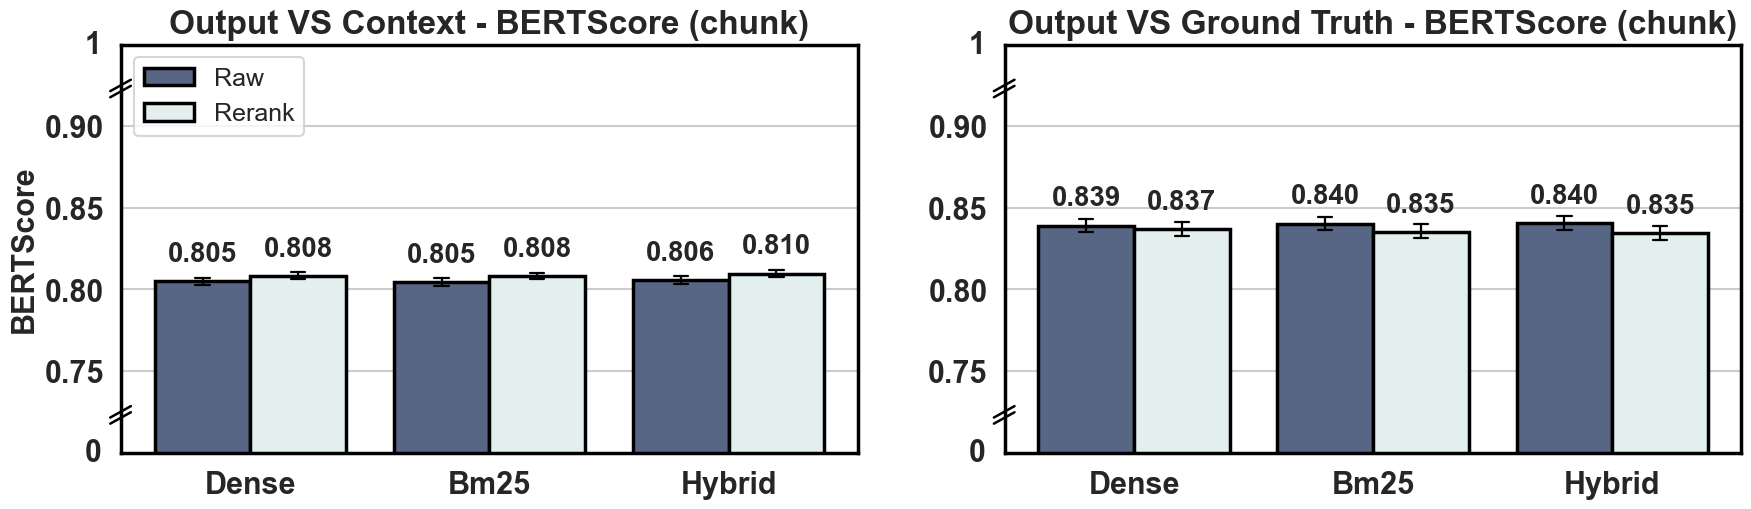

In [31]:
# -*- coding: utf-8 -*-
# RAG_AS / BERTScore style with omission marks + endpoint labels
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FormatStrFormatter
BASE_DIR = r"..\chunk\BERT_COS"
OUTPUT_PLOT_PATH = os.path.join(BASE_DIR, "Final_BERTScore_RowGrouped_OmissionStyle-chunktry.png")

MODES = ["Hybrid", "Dense", "Bm25"]

# ===== 全局字号设置 =====
FS_TITLE = 24         # 子图标题
FS_LABEL = 22         # x/y轴标题
FS_TICK = 22          # 坐标轴刻度
FS_ANNOT = 20         # 柱子上数值
FS_LEGEND = 18        # 图例文字
FS_LEGEND_TITLE = 18  # 图例标题

def load_bertscore_data():
    all_data = []

    for mode in MODES:
        folder_name = mode if mode != "Bm25" else "Bm25"
        csv_path = os.path.join(BASE_DIR, folder_name, "final_eval_AB_test.csv")

        if not os.path.exists(csv_path):
            alt_path = os.path.join(BASE_DIR, mode.capitalize(), "final_eval_AB_test.csv")
            if os.path.exists(alt_path):
                csv_path = alt_path
            else:
                print(f"⚠️ 警告: 找不到文件 {csv_path}")
                continue

        print(f"📥 正在加载 BERTScore 数据: {mode}")
        df = pd.read_csv(csv_path)

        for _, row in df.iterrows():
            all_data.append({'Mode': mode, 'Target': 'Context', 'Condition': 'Raw',    'Score': row['ctx_raw_bert']})
            all_data.append({'Mode': mode, 'Target': 'Context', 'Condition': 'Rerank', 'Score': row['ctx_rerank_bert']})
            all_data.append({'Mode': mode, 'Target': 'Answer',  'Condition': 'Raw',    'Score': row['ans_raw_bert']})
            all_data.append({'Mode': mode, 'Target': 'Answer',  'Condition': 'Rerank', 'Score': row['ans_rerank_bert']})

    return pd.DataFrame(all_data)


def annotate_bars(ax):
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{height:.3f}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=FS_ANNOT,
                fontweight='bold',
                xytext=(0, 10),
                textcoords='offset points'
            )


def style_spines(ax, lw=2.5):
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(lw)


def add_yaxis_omission_marks(ax, x=-0.018, y_bottom=0.03, y_top=0.97,
                             dx=0.018, dy=0.018, gap=0.014, lw=1.8):
    """
    在 y 轴靠近底部和顶部的位置画“折线省略符号”
    注意：不画在 0 和 1 标签正上面，而是稍微往里收一点
    """
    kwargs = dict(transform=ax.transAxes, color='black', clip_on=False, linewidth=lw)

    # 底部折线
    ax.plot((x - dx, x + dx), (y_bottom - dy, y_bottom + dy), **kwargs)
    ax.plot((x - dx, x + dx), (y_bottom - dy - gap, y_bottom + dy - gap), **kwargs)

    # 顶部折线
    ax.plot((x - dx, x + dx), (y_top - dy, y_top + dy), **kwargs)
    ax.plot((x - dx, x + dx), (y_top - dy - gap, y_top + dy - gap), **kwargs)


def add_endpoint_labels(ax, bottom_label="0", top_label="1", x_offset=-18):
    """
    在坐标轴最下端和最上端手动补 0 / 1，
    尽量让它们看起来像真正的 y 轴刻度标签
    """
    ticklabels = ax.get_yticklabels()
    fontsize = FS_TICK
    fontweight = 'normal'

    for lbl in ticklabels:
        txt = lbl.get_text().strip()
        if txt != "":
            fontsize = lbl.get_fontsize()
            fontweight = lbl.get_fontweight()
            break

    ax.annotate(
        bottom_label,
        xy=(0, 0), xycoords='axes fraction',
        xytext=(x_offset, 0), textcoords='offset points',
        ha='right', va='center',
        fontsize=fontsize,
        fontweight=fontweight,
        clip_on=False
    )

    ax.annotate(
        top_label,
        xy=(0, 1), xycoords='axes fraction',
        xytext=(x_offset, 0), textcoords='offset points',
        ha='right', va='center',
        fontsize=fontsize,
        fontweight=fontweight,
        clip_on=False
    )


def draw_single_panel(ax, subset, title, order, palette,
                      ylim, yticks=None, show_legend=False,
                      show_xlabel=True, show_ylabel=True,
                      show_omission=False, show_endpoint_labels=False):
    sns.barplot(
        data=subset,
        x="Mode",
        y="Score",
        hue="Condition",
        order=order,
        palette=palette,
        ax=ax,
        capsize=0.12,
        errcolor='black',
        errwidth=1.6,
        edgecolor='black',
        linewidth=2.5
    )

    # 子图标题
    ax.set_title(title, fontsize=FS_TITLE, fontweight='bold', pad=8)
    ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel("BERTScore", fontsize=FS_LABEL, fontweight='bold')
    else:
        ax.set_ylabel("")

    # 坐标轴刻度
    ax.set_xticklabels(order, fontsize=FS_TICK, fontweight='bold')
    ax.tick_params(axis='y', labelsize=FS_TICK)
    plt.setp(ax.get_yticklabels(), fontweight='bold')

    ax.set_ylim(*ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    annotate_bars(ax)
    style_spines(ax, lw=2.5)

    if show_omission:
        add_yaxis_omission_marks(
            ax,
            x=-0.001,
            y_bottom=0.10,
            y_top=0.90,
            dx=0.014,
            dy=0.014,
            gap=0.015,
            lw=1.8
        )

    if show_endpoint_labels:
        add_endpoint_labels(
            ax,
            bottom_label="0",
            top_label="1",
            x_offset=-14
        )

    # 图例
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            fontsize=FS_LEGEND,
            title_fontsize=FS_LEGEND_TITLE,
            loc='upper left'
        )
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()


def plot_bertscore(df):
    sns.set_theme(style="whitegrid", context="talk", font_scale=1.0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.20, wspace=0.20)

    palette = {"Raw":(80/255, 100/255, 140/255), 
           "Rerank": (225/255, 240/255, 240/255)  }
    order = ["Dense", "Bm25", "Hybrid"]

    ax_cb = axes[0]
    ax_ab = axes[1]

    subset_cb = df[df["Target"] == "Context"]
    subset_ab = df[df["Target"] == "Answer"]

    bert_ylim = (0.70, 0.95)
    bert_yticks = [0.75, 0.80, 0.85, 0.90]
    # bert_ylim = (0.75, 0.90)
    # bert_yticks = [0.78, 0.81, 0.84, 0.87]
    draw_single_panel(
        ax=ax_cb,
        subset=subset_cb,
        title="Output VS Context - BERTScore (chunk)",
        order=order,
        palette=palette,
        ylim=bert_ylim,
        yticks=bert_yticks,
        show_legend=True,
        show_xlabel=True,
        show_ylabel=True,
        show_omission=True,
        show_endpoint_labels=True
    )

    draw_single_panel(
        ax=ax_ab,
        subset=subset_ab,
        title="Output VS Ground Truth - BERTScore (chunk)",
        order=order,
        palette=palette,
        ylim=bert_ylim,
        yticks=bert_yticks,
        show_legend=False,
        show_xlabel=True,
        show_ylabel=False,
        show_omission=True,
        show_endpoint_labels=True
    )

    plt.savefig(OUTPUT_PLOT_PATH, dpi=300)   # 去掉 bbox_inches='tight'
    print(f"✅ BERTScore 图表已保存至: {OUTPUT_PLOT_PATH}")
    plt.show()


if __name__ == "__main__":
    df_bert = load_bertscore_data()
    if not df_bert.empty:
        plot_bertscore(df_bert)
    else:
        print("❌ 未加载到有效 BERTScore 数据，请检查 BASE_DIR")

In [107]:
# -*- coding: utf-8 -*-
# 计算 seaborn barplot 误差棒数值（按 mean + 95% bootstrap CI 思路）
import os
import numpy as np
import pandas as pd

BASE_DIR = r"..\chunk\BERT_COS"
OUTPUT_CSV = os.path.join(BASE_DIR, "barplot_errorbar_summary.csv")

MODES = ["Hybrid", "Dense", "Bm25"]
N_BOOT = 1000
CI = 95
RANDOM_SEED = 42


def load_all_data():
    all_data = []

    for mode in MODES:
        folder_name = mode if mode != "Bm25" else "Bm25"
        csv_path = os.path.join(BASE_DIR, folder_name, "final_eval_AB_test.csv")

        if not os.path.exists(csv_path):
            alt_path = os.path.join(BASE_DIR, mode.capitalize(), "final_eval_AB_test.csv")
            if os.path.exists(alt_path):
                csv_path = alt_path
            else:
                print(f"⚠️ 找不到文件: {csv_path}")
                continue

        print(f"📥 正在加载数据: {mode}")
        df = pd.read_csv(csv_path)

        for _, row in df.iterrows():
            # Cosine
            all_data.append({
                "Mode": mode, "Target": "Context", "Metric": "Cosine",
                "Condition": "Raw", "Score": row["ctx_raw_cos"]
            })
            all_data.append({
                "Mode": mode, "Target": "Context", "Metric": "Cosine",
                "Condition": "Rerank", "Score": row["ctx_rerank_cos"]
            })
            all_data.append({
                "Mode": mode, "Target": "Answer", "Metric": "Cosine",
                "Condition": "Raw", "Score": row["ans_raw_cos"]
            })
            all_data.append({
                "Mode": mode, "Target": "Answer", "Metric": "Cosine",
                "Condition": "Rerank", "Score": row["ans_rerank_cos"]
            })

            # BERTScore
            all_data.append({
                "Mode": mode, "Target": "Context", "Metric": "BERTScore",
                "Condition": "Raw", "Score": row["ctx_raw_bert"]
            })
            all_data.append({
                "Mode": mode, "Target": "Context", "Metric": "BERTScore",
                "Condition": "Rerank", "Score": row["ctx_rerank_bert"]
            })
            all_data.append({
                "Mode": mode, "Target": "Answer", "Metric": "BERTScore",
                "Condition": "Raw", "Score": row["ans_raw_bert"]
            })
            all_data.append({
                "Mode": mode, "Target": "Answer", "Metric": "BERTScore",
                "Condition": "Rerank", "Score": row["ans_rerank_bert"]
            })

    return pd.DataFrame(all_data)


def bootstrap_ci_mean(values, n_boot=1000, ci=95, seed=42):
    """对均值做 bootstrap，返回 (mean, ci_low, ci_high)"""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan

    mean_val = np.mean(values)

    # 样本数为1时，bootstrap 区间就退化成点
    if n == 1:
        return mean_val, mean_val, mean_val

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_means[i] = np.mean(sample)

    alpha = (100 - ci) / 2
    ci_low = np.percentile(boot_means, alpha)
    ci_high = np.percentile(boot_means, 100 - alpha)
    return mean_val, ci_low, ci_high


def summarize_errorbars(df):
    rows = []

    grouped = df.groupby(["Metric", "Target", "Mode", "Condition"], sort=False)

    for (metric, target, mode, condition), g in grouped:
        vals = g["Score"].dropna().to_numpy(dtype=float)

        n = len(vals)
        mean_val = np.mean(vals) if n > 0 else np.nan
        std_val = np.std(vals, ddof=1) if n > 1 else 0.0
        se_val = std_val / np.sqrt(n) if n > 1 else 0.0

        mean_boot, ci_low, ci_high = bootstrap_ci_mean(
            vals, n_boot=N_BOOT, ci=CI, seed=RANDOM_SEED
        )

        rows.append({
            "Metric": metric,
            "Target": target,
            "Mode": mode,
            "Condition": condition,
            "n": n,
            "mean": round(mean_boot, 6),
            "std": round(std_val, 6),
            "se": round(se_val, 6),
            "ci_low": round(ci_low, 6),
            "ci_high": round(ci_high, 6),
            "err_low": round(mean_boot - ci_low, 6),
            "err_high": round(ci_high - mean_boot, 6),
        })

    out = pd.DataFrame(rows)
    return out.sort_values(["Metric", "Target", "Mode", "Condition"]).reset_index(drop=True)


if __name__ == "__main__":
    df = load_all_data()

    if df.empty:
        print("❌ 没有加载到数据")
    else:
        summary = summarize_errorbars(df)

        print("\n================ 误差棒统计结果 ================\n")
        print(summary.to_string(index=False))

        summary.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
        print(f"\n✅ 已保存到: {OUTPUT_CSV}")

📥 正在加载数据: Hybrid
📥 正在加载数据: Dense
📥 正在加载数据: Bm25

================ 误差棒统计结果 ================

   Metric  Target   Mode Condition   n     mean      std       se   ci_low  ci_high  err_low  err_high
BERTScore  Answer   Bm25       Raw 111 0.840355 0.022586 0.002144 0.835921 0.844536 0.004433  0.004181
BERTScore  Answer   Bm25    Rerank 111 0.835356 0.024411 0.002317 0.830734 0.839542 0.004622  0.004186
BERTScore  Answer  Dense       Raw 111 0.839140 0.020893 0.001983 0.835245 0.843020 0.003895  0.003880
BERTScore  Answer  Dense    Rerank 111 0.836874 0.024605 0.002335 0.832596 0.841047 0.004277  0.004173
BERTScore  Answer Hybrid       Raw 111 0.840479 0.023215 0.002203 0.836136 0.844986 0.004343  0.004506
BERTScore  Answer Hybrid    Rerank 111 0.834583 0.021797 0.002069 0.830781 0.838978 0.003801  0.004395
BERTScore Context   Bm25       Raw 111 0.804696 0.013045 0.001238 0.802243 0.806944 0.002452  0.002249
BERTScore Context   Bm25    Rerank 111 0.808300 0.011353 0.001078 0.806065 0.810348 